# Realistic ERP simulation at one electrode

This notebook simulates smooth ERP-like EEG, focuses on one electrode, plots the ground-truth condition effect first, then fits the current LmeEEG model and plots the estimated condition kernel.

In [4]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd().resolve()
if not (repo_root / "src" / "lmeeeg").exists():
    repo_root = repo_root.parent

sys.path.insert(0, str(repo_root / "src"))

from lmeeeg.api.fit import fit_lmm_mass_univariate
from lmeeeg.api.simulate import simulate_erp_random_intercept_dataset

In [18]:
simulation = simulate_erp_random_intercept_dataset(
    n_subjects=20,
    n_trials_per_subject=15,
    n_channels=1,
    sampling_rate_hz=512.0,
    tmin_s=-0.1,
    tmax_s=0.35,
    include_channel_covariance=True,
    noise_sd=0.8,
    ar1_rho=0.6,
    seed=7,
)

electrode_index = 0
time_ms = simulation.time_ms

condition_a_mask = simulation.metadata["condition"] == "A"
condition_b_mask = simulation.metadata["condition"] == "B"

mean_a = simulation.eeg[condition_a_mask, electrode_index, :].mean(axis=0)
mean_b = simulation.eeg[condition_b_mask, electrode_index, :].mean(axis=0)
mean_difference = mean_b - mean_a

print(f"EEG shape: {simulation.eeg.shape}")
print(f"Selected electrode index: {electrode_index}")

EEG shape: (300, 1, 231)
Selected electrode index: 0


## Important interpretation

The default simulator includes both a P100 and an N200 in the trial-wise ERP signal, but only the N200 carries a condition effect by default.

That means:
- the P100 should be visible in the condition-average waveforms,
- but the P100 contribution to the ground-truth `condition[T.B]` beta is flat,
- because its default `amplitude_condition_effect` is `0.0`.

So a flat P100 in the ground-truth beta plot is expected and correct: it means the simulator put P100 into the ERP, not into the condition contrast.

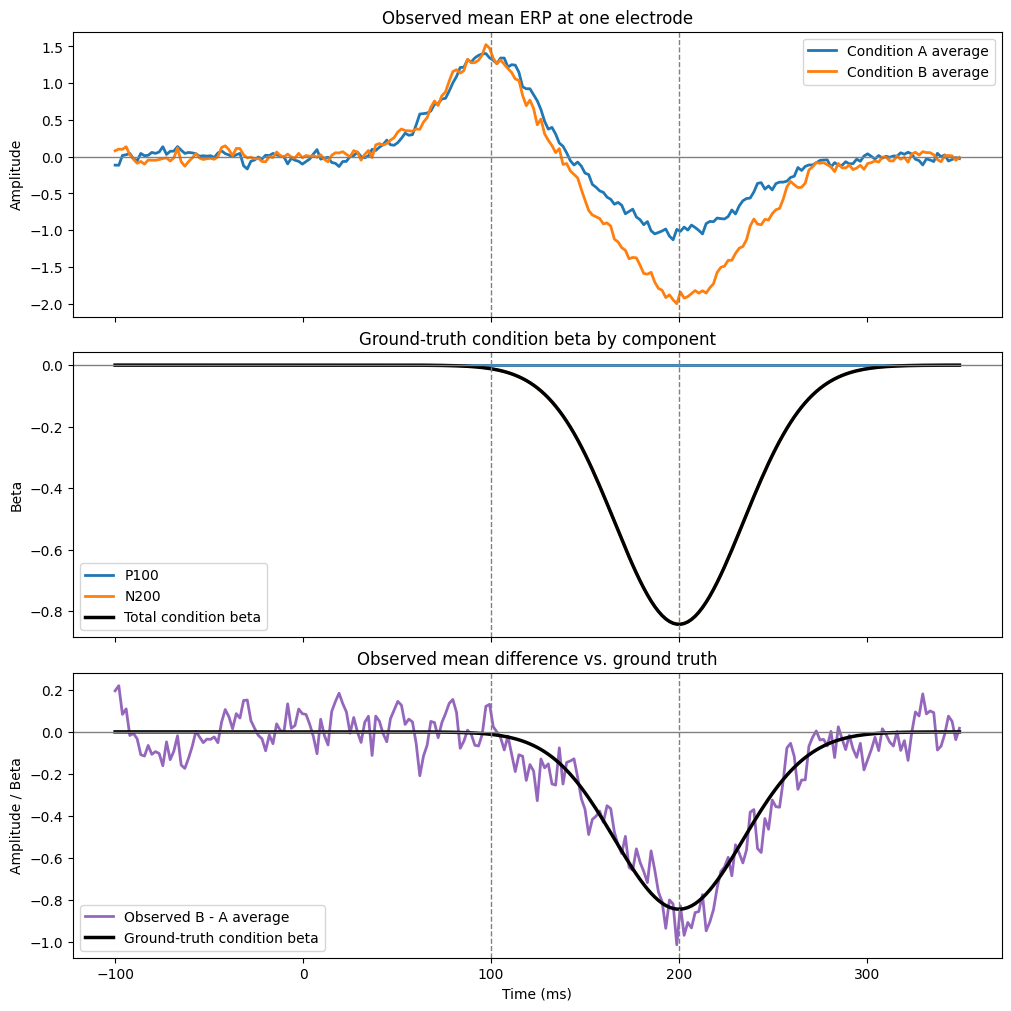

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True, constrained_layout=True)

axes[0].plot(time_ms, mean_a, linewidth=2, label="Condition A average")
axes[0].plot(time_ms, mean_b, linewidth=2, label="Condition B average")
axes[0].axhline(0.0, color="gray", linewidth=1)
axes[0].axvline(100.0, color="gray", linestyle="--", linewidth=1)
axes[0].axvline(200.0, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Observed mean ERP at one electrode")
axes[0].set_ylabel("Amplitude")
axes[0].legend()

for component_name, component_map in simulation.ground_truth_component_maps.items():
    axes[1].plot(time_ms, component_map[electrode_index], linewidth=2, label=component_name)
axes[1].plot(
    time_ms,
    simulation.ground_truth_beta_condition[electrode_index],
    color="black",
    linewidth=2.5,
    label="Total condition beta",
)
axes[1].axhline(0.0, color="gray", linewidth=1)
axes[1].axvline(100.0, color="gray", linestyle="--", linewidth=1)
axes[1].axvline(200.0, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Ground-truth condition beta by component")
axes[1].set_ylabel("Beta")
axes[1].legend()

axes[2].plot(time_ms, mean_difference, color="tab:purple", linewidth=2, label="Observed B - A average")
axes[2].plot(
    time_ms,
    simulation.ground_truth_beta_condition[electrode_index],
    color="black",
    linewidth=2.5,
    label="Ground-truth condition beta",
)
axes[2].axhline(0.0, color="gray", linewidth=1)
axes[2].axvline(100.0, color="gray", linestyle="--", linewidth=1)
axes[2].axvline(200.0, color="gray", linestyle="--", linewidth=1)
axes[2].set_title("Observed mean difference vs. ground truth")
axes[2].set_xlabel("Time (ms)")
axes[2].set_ylabel("Amplitude / Beta")
axes[2].legend()

plt.show()

The middle panel is the key one for interpretation.

Even though the average ERP above shows structure near both 100 ms and 200 ms, the default condition ground truth only lives around the N200. The flat P100 line does not mean the P100 is absent from the simulated signal. It means the P100 amplitude is not manipulated by condition in the default scenario.

In [26]:
fit_result = fit_lmm_mass_univariate(
    eeg=simulation.eeg,
    metadata=simulation.metadata,
    formula="y ~ condition + latency + (1|subject)",
    variable_types={
        "condition": "categorical",
        "latency": "numeric",
        "subject": "group",
    },
)

fit_result.convergence_summary

ConvergenceSummary(n_features=231, n_converged=230, n_failed=1, convergence_rate=0.9956709956709957, n_boundary_warnings=148)

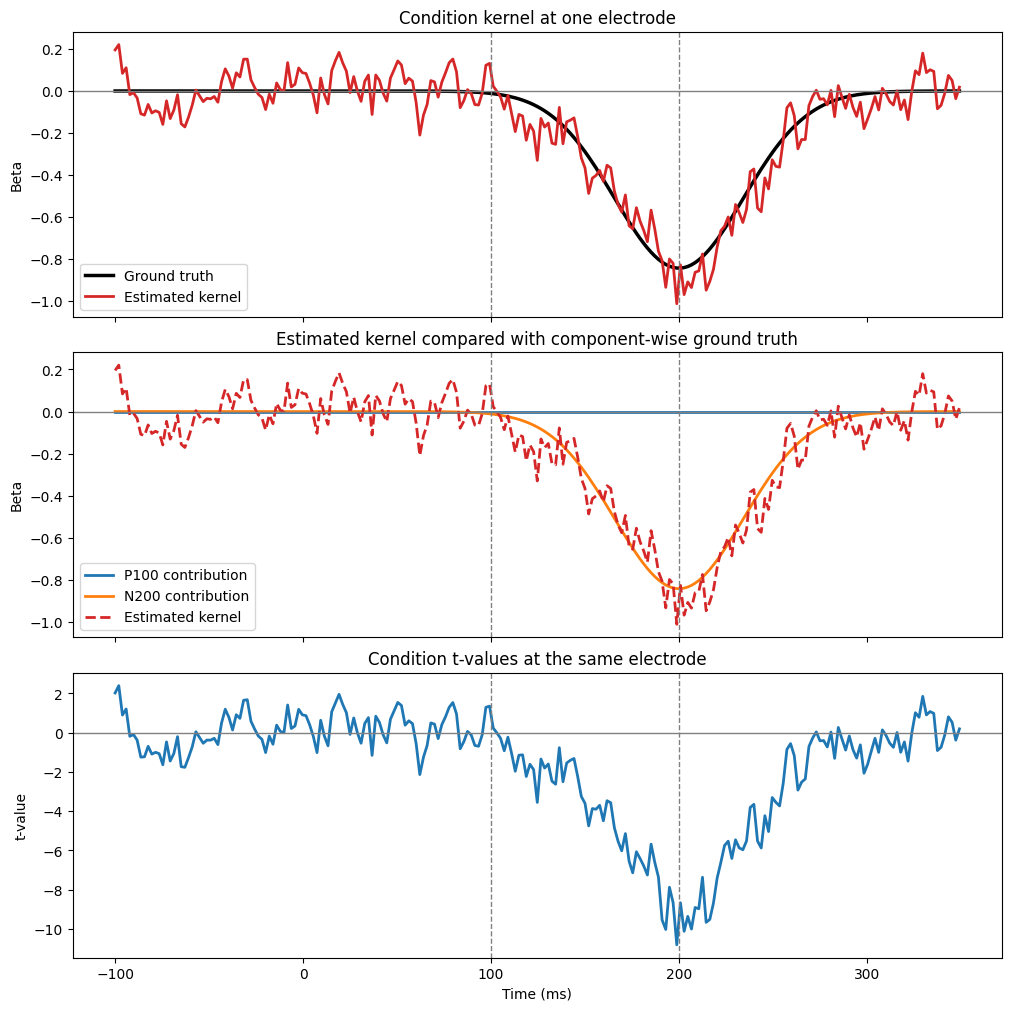

In [27]:
estimated_kernel = fit_result.ols_betas["condition[T.B]"][electrode_index]
estimated_t_values = fit_result.ols_t_values["condition[T.B]"][electrode_index]

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True, constrained_layout=True)

axes[0].plot(
    time_ms,
    simulation.ground_truth_beta_condition[electrode_index],
    color="black",
    linewidth=2.5,
    label="Ground truth",
)
axes[0].plot(time_ms, estimated_kernel, color="tab:red", linewidth=2, label="Estimated kernel")
axes[0].axhline(0.0, color="gray", linewidth=1)
axes[0].axvline(100.0, color="gray", linestyle="--", linewidth=1)
axes[0].axvline(200.0, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Condition kernel at one electrode")
axes[0].set_ylabel("Beta")
axes[0].legend()

for component_name, component_map in simulation.ground_truth_component_maps.items():
    axes[1].plot(time_ms, component_map[electrode_index], linewidth=2, label=f"{component_name} contribution")
axes[1].plot(time_ms, estimated_kernel, color="tab:red", linewidth=2, linestyle="--", label="Estimated kernel")
axes[1].axhline(0.0, color="gray", linewidth=1)
axes[1].axvline(100.0, color="gray", linestyle="--", linewidth=1)
axes[1].axvline(200.0, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Estimated kernel compared with component-wise ground truth")
axes[1].set_ylabel("Beta")
axes[1].legend()

axes[2].plot(time_ms, estimated_t_values, color="tab:blue", linewidth=2)
axes[2].axhline(0.0, color="gray", linewidth=1)
axes[2].axvline(100.0, color="gray", linestyle="--", linewidth=1)
axes[2].axvline(200.0, color="gray", linestyle="--", linewidth=1)
axes[2].set_title("Condition t-values at the same electrode")
axes[2].set_xlabel("Time (ms)")
axes[2].set_ylabel("t-value")

plt.show()